# Classifier Morph Test

`services/forest_mask/cli.py` で追加された `anomaly_morph` / `healthy_morph` を確認するノートブック。

- `classify_forest_status` で得た `healthy_mask` / `anomaly_mask` に対し、 `apply_morphology` (closing -> opening) を適用する。
- closing で小さな穴を埋め、 opening で小さなノイズを除去する。
- 適用前後を可視化し、ピクセル数の変化を比較する。

入力: `data/input/jpg/sample/sample_tree.jpg`

In [1]:
# プロジェクトルートで実行できるようにカレントを移動
import os
from pathlib import Path

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
    os.chdir(PROJECT_ROOT)

print("cwd:", Path.cwd())

cwd: /home/mqsol/works/forest-analyzer


In [2]:
# モジュールリロードを有効化
%load_ext autoreload
%autoreload 2

In [3]:
# パラメータ (CLI のデフォルトに合わせる)
INPUT_PATH = Path("data/input/jpg/sample/sample_tree.jpg")

EXG_THRESHOLD = 10.0
SAT_TH = 80.0
LAB_A_TH = 125.0
ANOMALY_SAT_TH = 60.0
ANOMALY_VAL_TH = 170.0
TEXTURE_KERNEL = 5
TEXTURE_TH = 5.0

CLOSING = 5
OPENING = 3

In [4]:
# 特徴量計算 & 分類
from services.common.image import load_rgb
from services.forest_mask.exg import calc_exg
from services.forest_mask.color import calc_hsv, calc_lab
from services.forest_mask.texture import calc_texture
from services.forest_mask.classifier import classify_forest_status
from services.forest_mask.morphology import apply_morphology

rgb = load_rgb(INPUT_PATH)
exg = calc_exg(rgb)
hsv_h, hsv_s, hsv_v = calc_hsv(rgb)
lab_l, lab_a, lab_b = calc_lab(rgb)
texture = calc_texture(exg, TEXTURE_KERNEL)

healthy_mask, anomaly_mask, unknown_mask = classify_forest_status(
    exg=exg,
    s=hsv_s,
    v=hsv_v,
    lab_a=lab_a,
    texture=texture,
    exg_threshold=EXG_THRESHOLD,
    saturation_threshold=SAT_TH,
    lab_a_threshold=LAB_A_TH,
    anomaly_saturation_threshold=ANOMALY_SAT_TH,
    anomaly_value_threshold=ANOMALY_VAL_TH,
    texture_threshold=TEXTURE_TH,
)

# モルフォロジー適用
anomaly_morph = apply_morphology(anomaly_mask, CLOSING, OPENING)
healthy_morph = apply_morphology(healthy_mask, CLOSING, OPENING)

total = rgb.shape[0] * rgb.shape[1]
rows = [
    ("healthy_mask", healthy_mask),
    ("healthy_morph", healthy_morph),
    ("anomaly_mask", anomaly_mask),
    ("anomaly_morph", anomaly_morph),
]
for name, m in rows:
    pix = int(m.sum())
    print(f"{name:14s}: {pix:>10d} px  ({pix / total * 100:5.2f}%)")

healthy_mask  :     450393 px  (14.34%)
healthy_morph :     783032 px  (24.92%)
anomaly_mask  :     286567 px  ( 9.12%)
anomaly_morph :     441677 px  (14.06%)


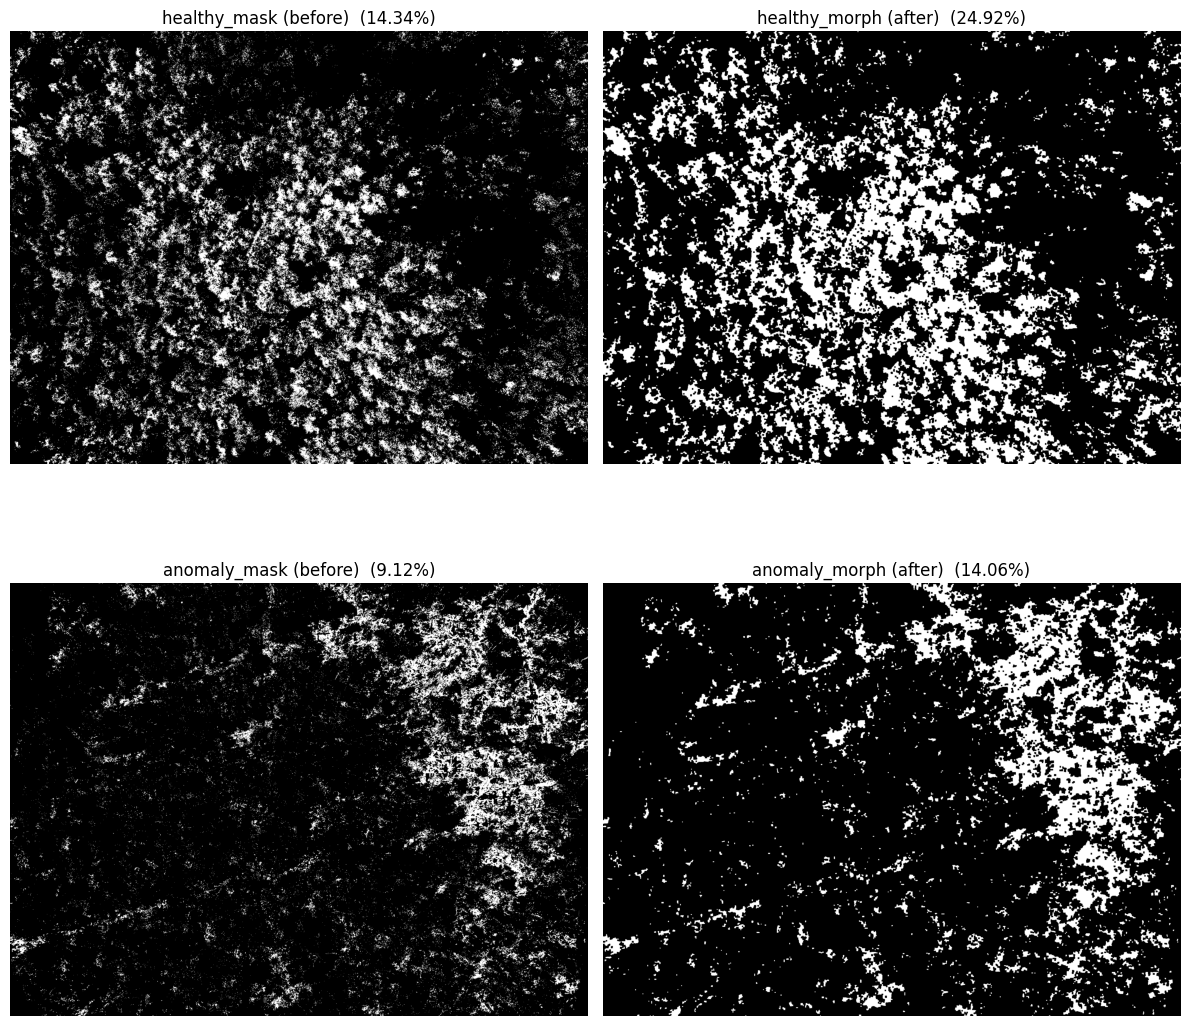

In [5]:
# 適用前後を 2x2 で並べて比較
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 12))

panels = [
    (axes[0, 0], healthy_mask, "healthy_mask (before)"),
    (axes[0, 1], healthy_morph, "healthy_morph (after)"),
    (axes[1, 0], anomaly_mask, "anomaly_mask (before)"),
    (axes[1, 1], anomaly_morph, "anomaly_morph (after)"),
]
for ax, mask, title in panels:
    ax.imshow(mask, cmap="gray", vmin=0, vmax=1)
    pix = int(mask.sum())
    ax.set_title(f"{title}  ({pix / total * 100:.2f}%)")
    ax.axis("off")

plt.tight_layout()
plt.show()

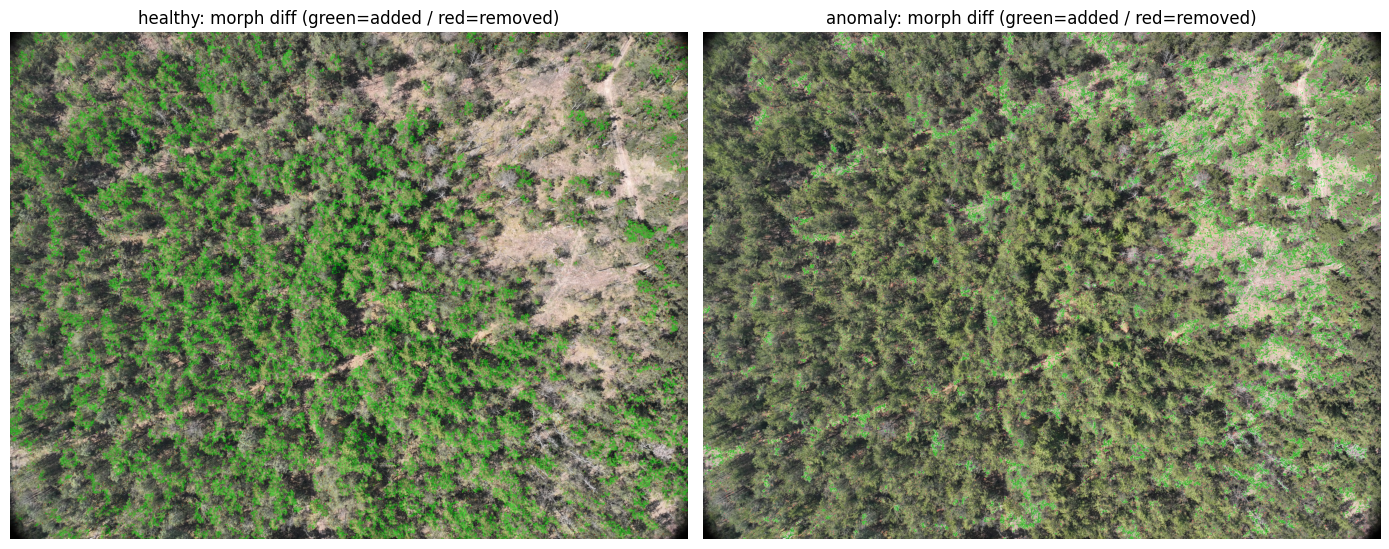

In [6]:
# モルフォロジーによる変化点を可視化
#   追加された画素 = 緑 (closing で穴埋めされた領域)
#   削除された画素 = 赤 (opening で除去されたノイズ)
import numpy as np


def diff_overlay(rgb_img: np.ndarray, before: np.ndarray, after: np.ndarray, alpha: float = 0.55) -> np.ndarray:
    added = after & ~before
    removed = before & ~after
    out = rgb_img.astype(np.float32).copy()
    green = np.array([0, 220, 0], dtype=np.float32)
    red = np.array([220, 30, 30], dtype=np.float32)
    out[added] = (1 - alpha) * out[added] + alpha * green
    out[removed] = (1 - alpha) * out[removed] + alpha * red
    return np.clip(out, 0, 255).astype(np.uint8)


healthy_diff = diff_overlay(rgb, healthy_mask, healthy_morph)
anomaly_diff = diff_overlay(rgb, anomaly_mask, anomaly_morph)

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
axes[0].imshow(healthy_diff)
axes[0].set_title("healthy: morph diff (green=added / red=removed)")
axes[0].axis("off")
axes[1].imshow(anomaly_diff)
axes[1].set_title("anomaly: morph diff (green=added / red=removed)")
axes[1].axis("off")
plt.tight_layout()
plt.show()

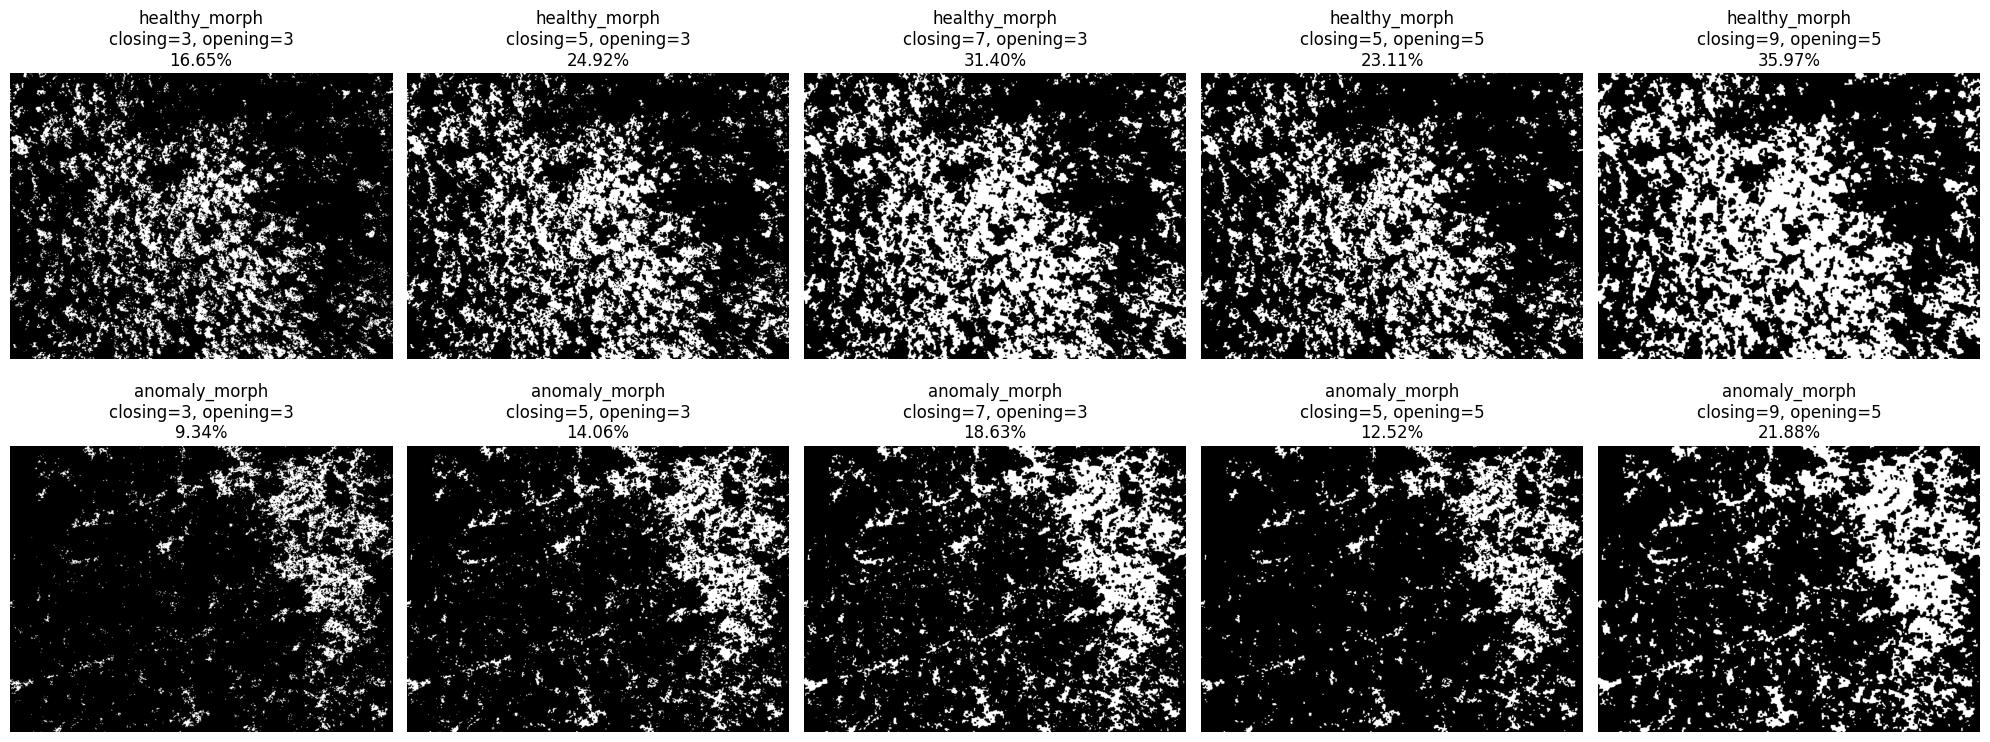

In [7]:
# closing / opening のカーネルサイズを変えて挙動を確認
param_sets = [
    (3, 3),
    (5, 3),
    (7, 3),
    (5, 5),
    (9, 5),
]

fig, axes = plt.subplots(2, len(param_sets), figsize=(4 * len(param_sets), 8))
for col, (c, o) in enumerate(param_sets):
    hm = apply_morphology(healthy_mask, c, o)
    am = apply_morphology(anomaly_mask, c, o)

    axes[0, col].imshow(hm, cmap="gray", vmin=0, vmax=1)
    axes[0, col].set_title(f"healthy_morph\nclosing={c}, opening={o}\n{hm.sum() / total * 100:.2f}%")
    axes[0, col].axis("off")

    axes[1, col].imshow(am, cmap="gray", vmin=0, vmax=1)
    axes[1, col].set_title(f"anomaly_morph\nclosing={c}, opening={o}\n{am.sum() / total * 100:.2f}%")
    axes[1, col].axis("off")

plt.tight_layout()
plt.show()